# Telco Customer Churn Prediction

## Overview
This project predicts customer churn using the Telco Customer Churn dataset.

## Tasks Performed
- Loaded customer data
- Cleaned missing and incorrect values
- Converted data types
- Performed feature engineering
- Trained classification models
- Evaluated model performance

## Libraries Used
- Pandas
- NumPy
- Scikit-learn

## Goal
Predict whether a customer is likely to leave the telecom service.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = df['TotalCharges'].astype(float)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [10]:
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = [col for col in X.columns if col not in numerical_cols]




In [15]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

In [18]:
from sklearn.ensemble import RandomForestClassifier


In [19]:
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
    ]
)

In [21]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
y_pred = pipeline.predict(X_test)

In [23]:
y_scores = pipeline.predict_proba(X_test)[:, 1]

In [20]:
from sklearn.metrics import classification_report, precision_recall_curve

In [24]:
print(classification_report(y_test, y_pred))

precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)
optimal_idx = np.argmax(2 * (precisions * recalls) / (precisions + recalls + 1e-10))
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal Decision Threshold for F1-Score: {optimal_threshold:.4f}")

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

Optimal Decision Threshold for F1-Score: 0.2600


In [25]:
import matplotlib.pyplot as plt

In [26]:

y_pred_optimal = (y_scores >= 0.2600).astype(int)
print(classification_report(y_test, y_pred_optimal))

feature_names = numerical_cols + list(pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols))
importances = pipeline.named_steps['classifier'].feature_importances_

df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False).head(10)
print(df_importance)

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

                           Feature  Importance
2                     TotalCharges    0.174931
0                           tenure    0.174145
1                   MonthlyCharges    0.152241
25               Contract_Two year    0.057885
28  PaymentMethod_Electronic check    0.041549
10     InternetService_Fiber optic    0.039104
13              OnlineSecurity_Yes    0.027194
24               Contract_One year    0.026902
3                      gender_Male    0.025481
26            PaperlessBilling_Yes    0.024348


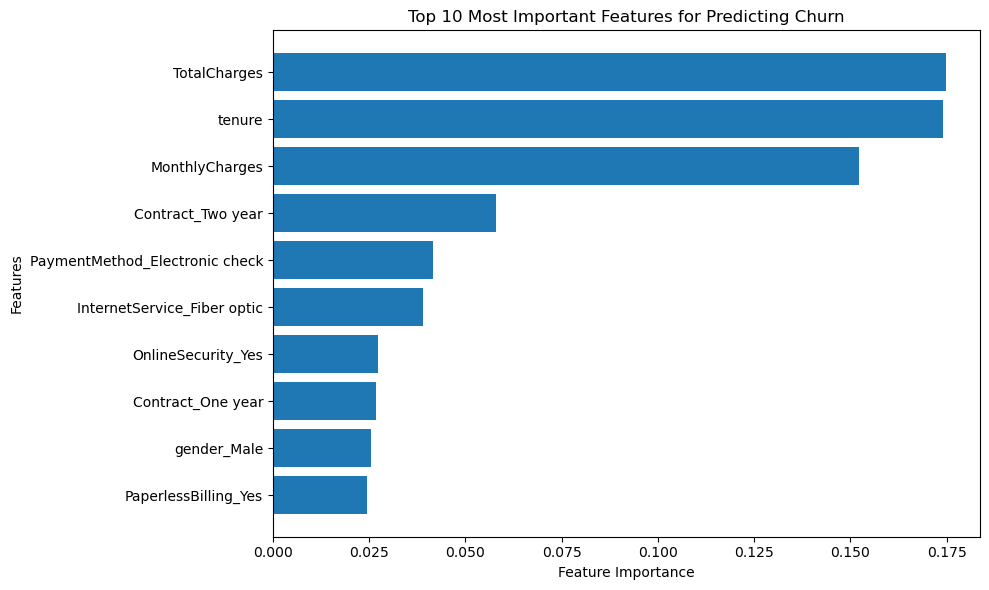

In [27]:
plt.figure(figsize=(10, 6))
plt.barh(df_importance['Feature'][::-1], df_importance['Importance'][::-1])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 10 Most Important Features for Predicting Churn')
plt.tight_layout()
plt.show()

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [31]:
import seaborn as sns

          FINANCIAL IMPACT ANALYSIS          
Cost of Missed Churners (FN):   $  40,000
Cost of Unnecessary Campaigns (FP): $  14,600
---------------------------------------------
TOTAL OPERATIONAL RISK COST:    $  54,600


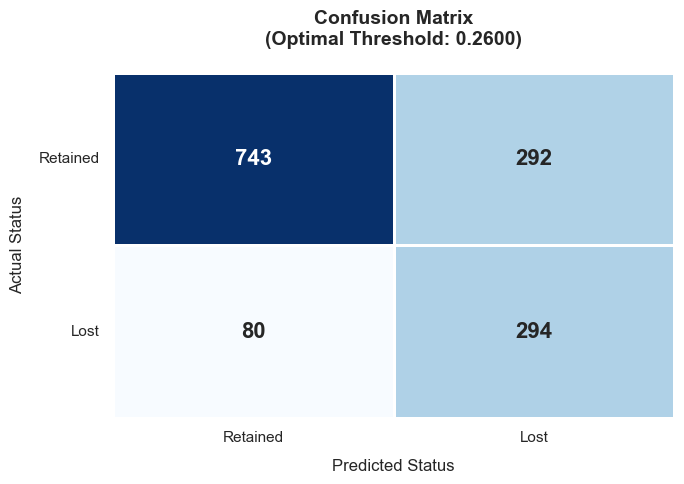

In [32]:
print("=" * 45)
print(f"{'FINANCIAL IMPACT ANALYSIS':^45}")
print("=" * 45)
print(f"Cost of Missed Churners (FN):   ${cost_fn:>8,}")
print(f"Cost of Unnecessary Campaigns (FP): ${cost_fp:>8,}")
print("-" * 45)
print(f"TOTAL OPERATIONAL RISK COST:    ${cost_fn + cost_fp:>8,}")
print("=" * 45)

plt.figure(figsize=(7, 5))
sns.set_theme(style="white")

ax = sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    cbar=False,
    linewidths=2,
    linecolor="white",
    annot_kws={"size": 16, "weight": "bold"}
)

ax.set_title("Confusion Matrix\n(Optimal Threshold: 0.2600)", fontsize=14, pad=20, weight="bold")
ax.set_xlabel("Predicted Status", fontsize=12, labelpad=10)
ax.set_ylabel("Actual Status", fontsize=12, labelpad=10)
ax.set_xticklabels(["Retained", "Lost"], fontsize=11)
ax.set_yticklabels(["Retained", "Lost"], fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

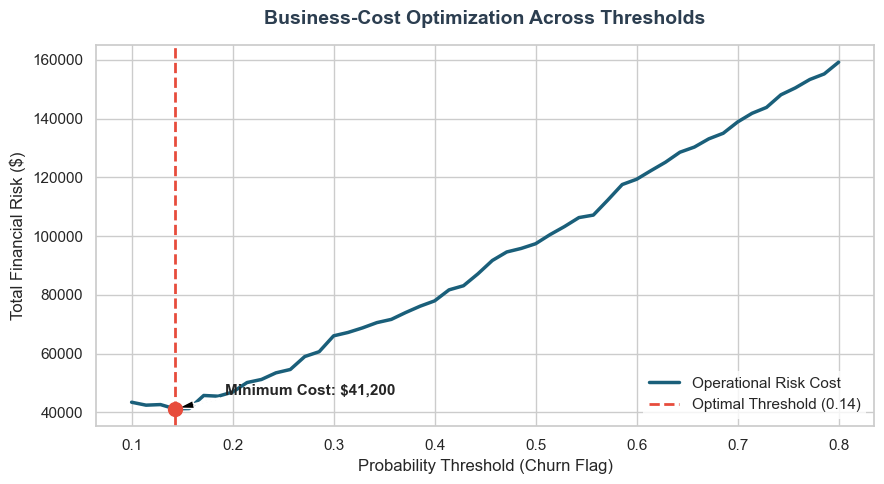

In [35]:
thresholds = np.linspace(0.1, 0.8, 50)
total_costs = []

for t in thresholds:
    y_pred_t = (y_scores >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    cost = (cm_t[1, 0] * 500) + (cm_t[0, 1] * 50)
    total_costs.append(cost)

best_threshold = thresholds[np.argmin(total_costs)]
min_cost = min(total_costs)

plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

plt.plot(thresholds, total_costs, color='#1a5f7a', linewidth=2.5, label='Operational Risk Cost')
plt.axvline(best_threshold, color='#e74c3c', linestyle='--', linewidth=2, label=f'Optimal Threshold ({best_threshold:.2f})')
plt.scatter(best_threshold, min_cost, color='#e74c3c', s=100, zorder=5)

plt.title('Business-Cost Optimization Across Thresholds', fontsize=14, pad=15, weight='bold', color='#2c3e50')
plt.xlabel('Probability Threshold (Churn Flag)', fontsize=12)
plt.ylabel('Total Financial Risk ($)', fontsize=12)
plt.annotate(f'Minimum Cost: ${min_cost:,}', 
             xy=(best_threshold, min_cost), 
             xytext=(best_threshold + 0.05, min_cost + 5000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
             fontsize=11, weight='bold')

plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

        PRODUCTION DEPLOYMENT READY REPORT        
Selected Business Threshold: 0.1429
Minimized Operational Risk Cost: $41,200
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.58      0.72      1035
           1       0.44      0.90      0.59       374

    accuracy                           0.66      1409
   macro avg       0.69      0.74      0.65      1409
weighted avg       0.81      0.66      0.68      1409



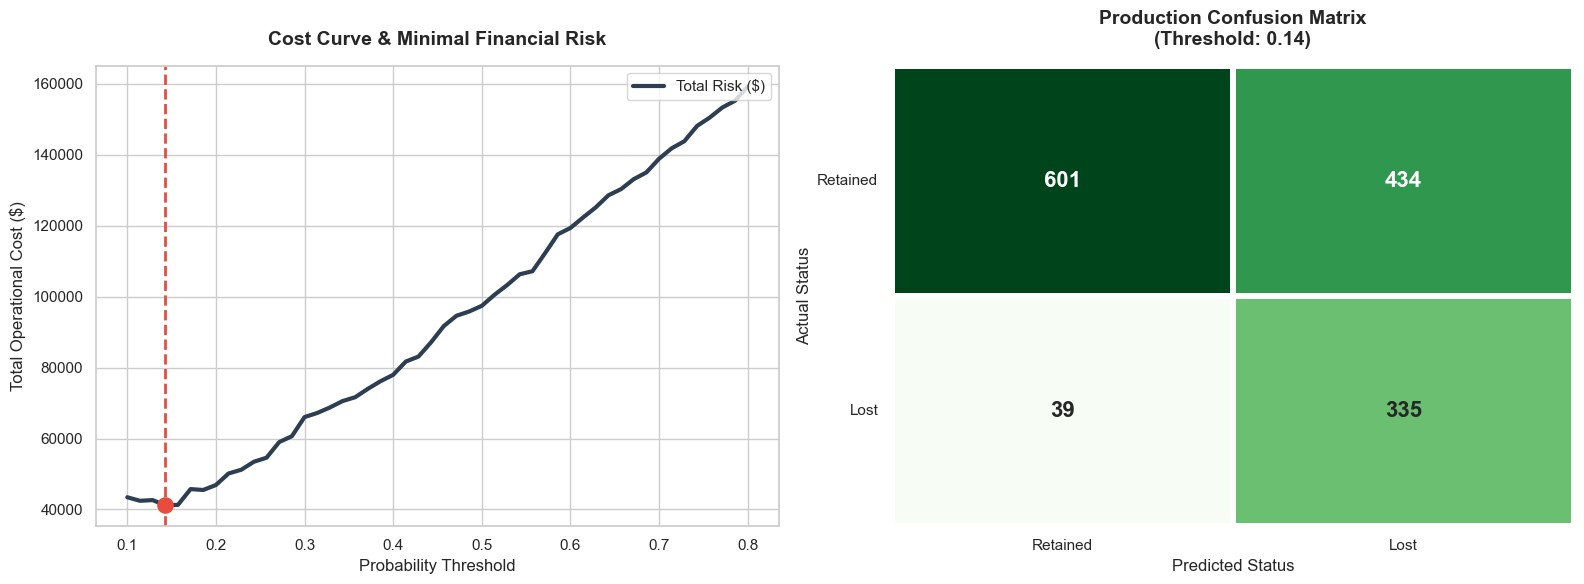

In [36]:
optimal_idx = np.argmin(total_costs)
final_threshold = thresholds[optimal_idx]
final_cost = total_costs[optimal_idx]

y_pred_final = (y_scores >= final_threshold).astype(int)
final_cm = confusion_matrix(y_test, y_pred_final)

print("=" * 50)
print(f"{'PRODUCTION DEPLOYMENT READY REPORT':^50}")
print("=" * 50)
print(f"Selected Business Threshold: {final_threshold:.4f}")
print(f"Minimized Operational Risk Cost: ${final_cost:,}")
print("-" * 50)
print(classification_report(y_test, y_pred_final))
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

axes[0].plot(thresholds, total_costs, color='#2c3e50', linewidth=3, label='Total Risk ($)')
axes[0].axvline(final_threshold, color='#e74c3c', linestyle='--', linewidth=2)
axes[0].scatter(final_threshold, final_cost, color='#e74c3c', s=120, zorder=5)
axes[0].set_title('Cost Curve & Minimal Financial Risk', fontsize=14, weight='bold', pad=15)
axes[0].set_xlabel('Probability Threshold', fontsize=12)
axes[0].set_ylabel('Total Operational Cost ($)', fontsize=12)
axes[0].legend(loc='upper right')

sns.heatmap(
    final_cm, 
    annot=True, 
    fmt="d", 
    cmap="Greens", 
    cbar=False,
    linewidths=3,
    linecolor="white",
    annot_kws={"size": 16, "weight": "bold"},
    ax=axes[1]
)
axes[1].set_title(f'Production Confusion Matrix\n(Threshold: {final_threshold:.2f})', fontsize=14, weight='bold', pad=15)
axes[1].set_xlabel('Predicted Status', fontsize=12)
axes[1].set_ylabel('Actual Status', fontsize=12)
axes[1].set_xticklabels(['Retained', 'Lost'], fontsize=11)
axes[1].set_yticklabels(['Retained', 'Lost'], fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

In [37]:
import joblib

joblib.dump(pipeline, 'telco_churn_production_model.pkl')

print("=" * 50)
print(f"{'PIPELINE EXPORT SUCCESSFUL':^50}")
print("=" * 50)
print("Model Artifact: telco_churn_production_model.pkl")
print(f"Target Operational Threshold: {final_threshold:.4f}")
print("Deployment Status: READY FOR INFRASTRUCTURE STAGE")
print("=" * 50)

            PIPELINE EXPORT SUCCESSFUL            
Model Artifact: telco_churn_production_model.pkl
Target Operational Threshold: 0.1429
Deployment Status: READY FOR INFRASTRUCTURE STAGE


In [38]:
from sklearn.inspection import permutation_importance

In [40]:
result = permutation_importance(
    pipeline, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

df_perm = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

print("=" * 60)
print(f"{'PRODUCTION ETHICS & ETHICAL AUDIT REPORT':^60}")
print("=" * 60)

df_test_audit = X_test.copy()
df_test_audit['Actual_Churn'] = y_test
df_test_audit['Predicted_Churn'] = y_pred_final

audit_features = {
    'gender': ['Female', 'Male'],
    'SeniorCitizen': [0, 1]
}

for group, values in audit_features.items():
    print(f"\nFairness Metrics for Demographic Feature: {group}")
    print("-" * 60)
    for val in values:
        sub_df = df_test_audit[df_test_audit[group] == val]
        
        if len(sub_df) == 0:
            continue
            
        sub_cm = confusion_matrix(sub_df['Actual_Churn'], sub_df['Predicted_Churn'])
        
        tn, fp, fn, tp = sub_cm.ravel() if sub_cm.size == 4 else (0, 0, 0, 0)
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        
        print(f"Subgroup Value {str(val):.<10} | False Positive Rate: {fpr:.4f} | False Negative Rate: {fnr:.4f}")
print("=" * 60)

          PRODUCTION ETHICS & ETHICAL AUDIT REPORT          

Fairness Metrics for Demographic Feature: gender
------------------------------------------------------------
Subgroup Value Female.... | False Positive Rate: 0.4089 | False Negative Rate: 0.0881
Subgroup Value Male...... | False Positive Rate: 0.4288 | False Negative Rate: 0.1215

Fairness Metrics for Demographic Feature: SeniorCitizen
------------------------------------------------------------
Subgroup Value 0......... | False Positive Rate: 0.3831 | False Negative Rate: 0.1377
Subgroup Value 1......... | False Positive Rate: 0.6855 | False Negative Rate: 0.0102
